In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error , mean_squared_error
from sklearn.linear_model import LinearRegression ,LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)
sns.set_theme(style='whitegrid')
print('All libraries imported successfully.')

pd.set_option("display.max_columns", None)
np.random.seed(42)


All libraries imported successfully.


In [2]:
data = pd.read_csv("./gym_members_massive.csv")

In [3]:
data.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [4]:
data.isnull().sum()

,0
Age,0
Gender,0
Weight (kg),0
Height (m),0
Max_BPM,0
Avg_BPM,0
Resting_BPM,0
Session_Duration (hours),0
Calories_Burned,0
Workout_Type,0


In [5]:
data.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,38.594000,74.123670,1.725305,179.888200,143.7700,62.309700,1.254380,906.25190,24.901220,2.632890,3.348000,1.86630,24.955935
std,12.312162,21.260949,0.130012,11.709424,14.3847,7.440519,0.357044,277.03789,6.411636,0.643637,1.036245,0.80093,6.775409
min,18.000000,40.000000,1.500000,160.000000,120.0000,50.000000,0.500000,303.00000,10.000000,1.500000,2.000000,1.00000,10.770000
25%,28.000000,58.300000,1.620000,170.000000,132.0000,56.000000,1.020000,714.00000,21.000000,2.100000,2.000000,1.00000,20.150000
50%,39.000000,70.000000,1.720000,180.000000,143.0000,63.000000,1.260000,898.00000,26.000000,2.600000,3.000000,2.00000,24.240000
75%,49.000000,86.100000,1.810000,190.000000,156.0000,69.000000,1.490000,1085.00000,29.500000,3.200000,4.000000,3.00000,28.732500
max,59.000000,129.900000,2.000000,199.000000,169.0000,74.000000,2.000000,1783.00000,35.000000,3.700000,5.000000,3.00000,54.730000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            10000 non-null  int64  
 1   Gender                         10000 non-null  object 
 2   Weight (kg)                    10000 non-null  float64
 3   Height (m)                     10000 non-null  float64
 4   Max_BPM                        10000 non-null  int64  
 5   Avg_BPM                        10000 non-null  int64  
 6   Resting_BPM                    10000 non-null  int64  
 7   Session_Duration (hours)       10000 non-null  float64
 8   Calories_Burned                10000 non-null  float64
 9   Workout_Type                   10000 non-null  object 
 10  Fat_Percentage                 10000 non-null  float64
 11  Water_Intake (liters)          10000 non-null  float64
 12  Workout_Frequency (days/week)  10000 non-null  

In [7]:
data.shape

(10000, 15)

In [8]:
data.nunique()

,0
Age,42
Gender,2
Weight (kg),893
Height (m),51
Max_BPM,40
Avg_BPM,50
Resting_BPM,25
Session_Duration (hours),151
Calories_Burned,1314
Workout_Type,4


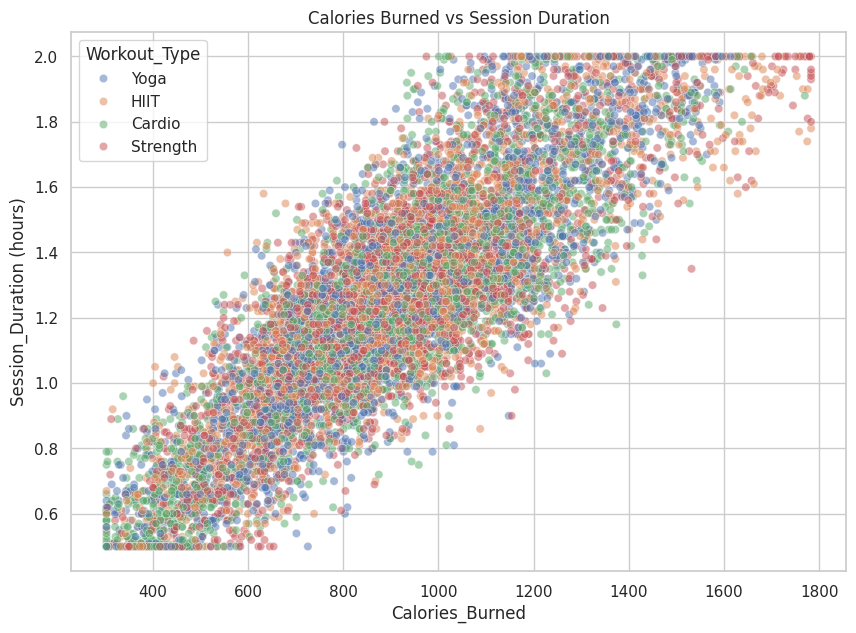

In [9]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=data, x="Calories_Burned", y="Session_Duration (hours)", hue="Workout_Type", alpha=0.5)
plt.title("Calories Burned vs Session Duration")
plt.show()

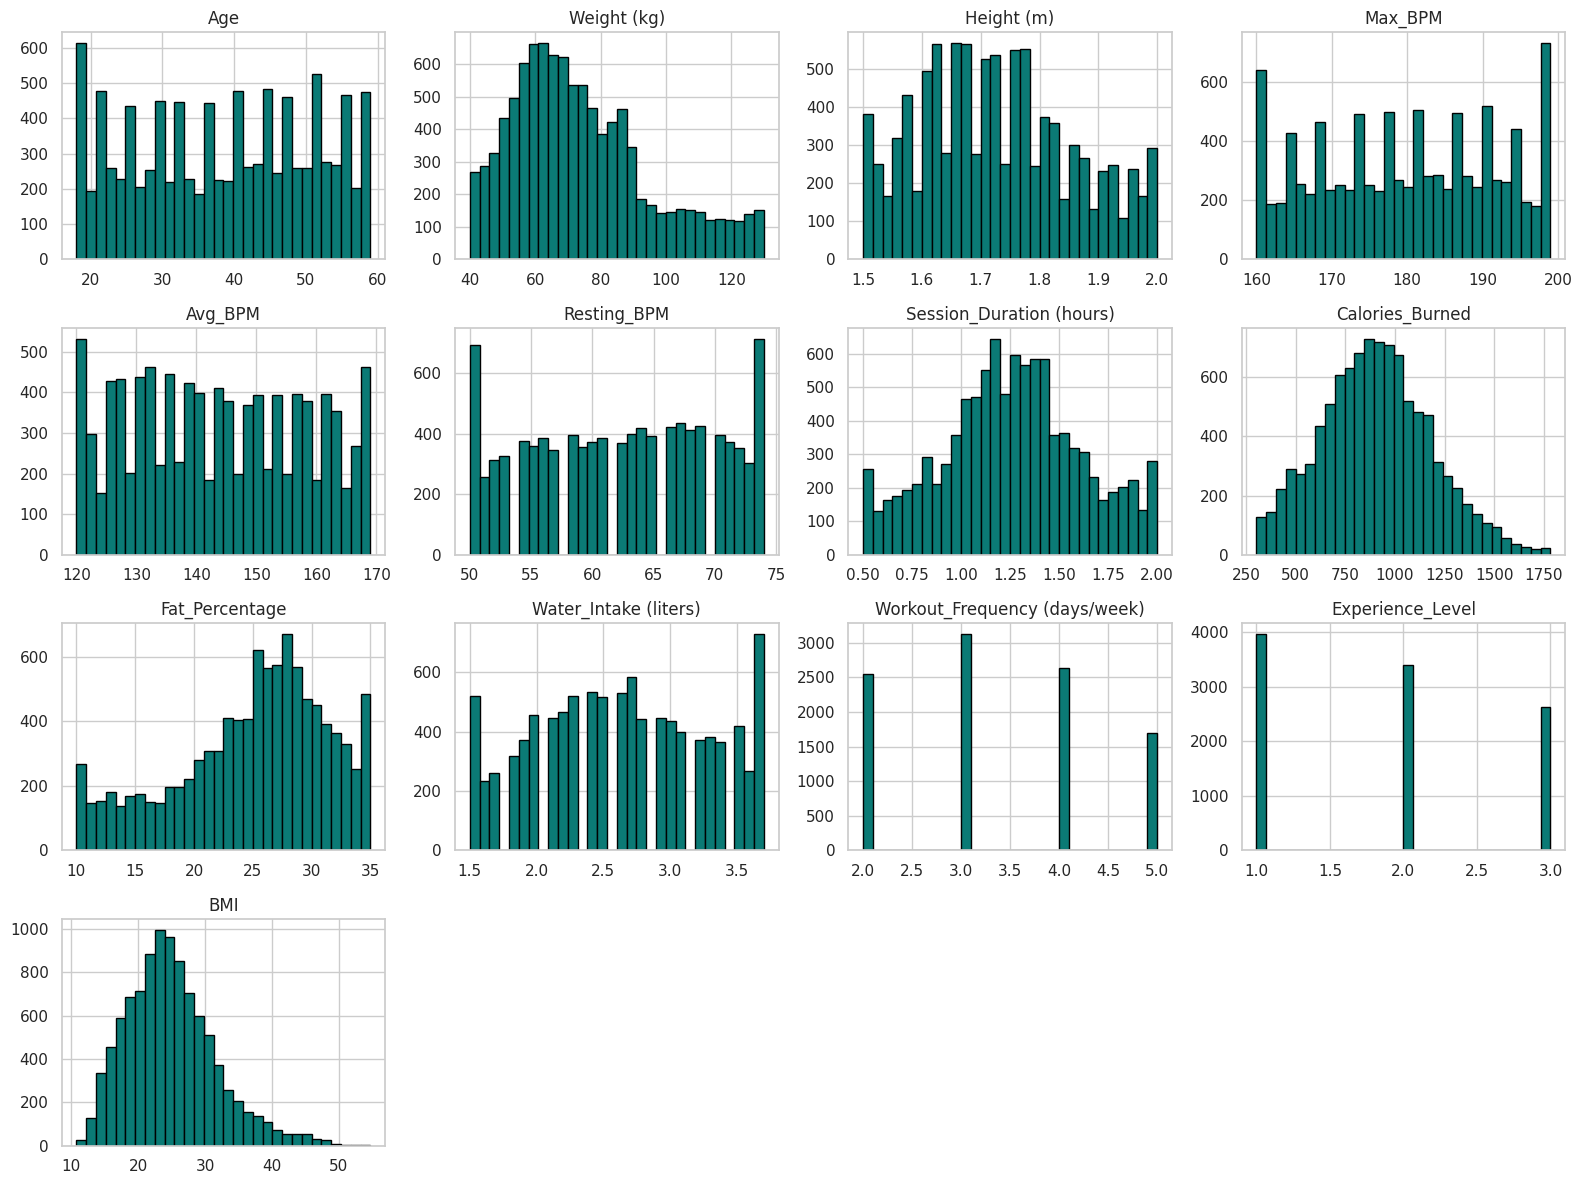

In [10]:
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
data[numeric_cols].hist(figsize=(16, 12), bins=30, color='#0B7A75', edgecolor='black')
plt.tight_layout()
plt.show()

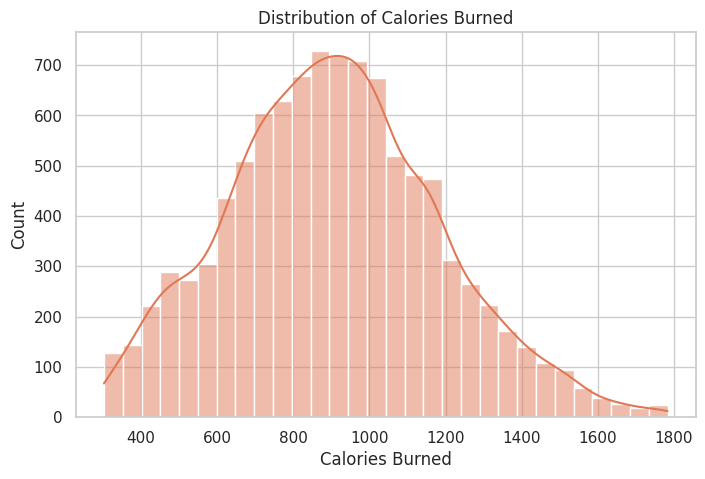

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(data['Calories_Burned'], bins=30, kde=True, color='#E07856')
plt.title('Distribution of Calories Burned')
plt.xlabel('Calories Burned')
plt.ylabel('Count')
plt.show()

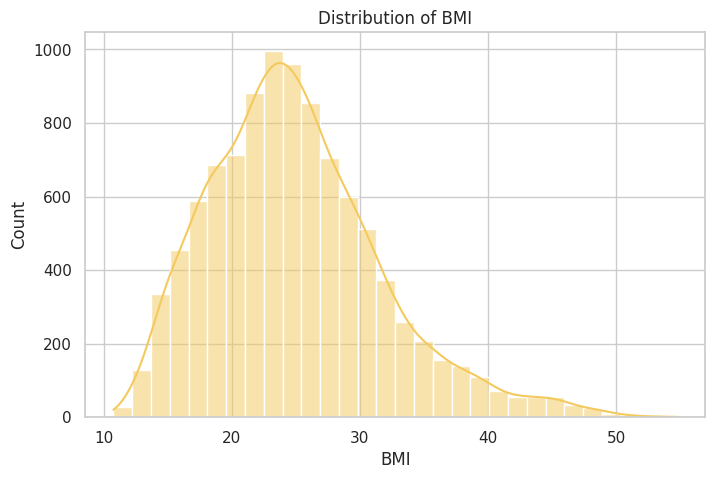

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(data['BMI'], bins=30, kde=True, color='#F4C95D')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_13099/458247299.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Gender', palette='Set2')


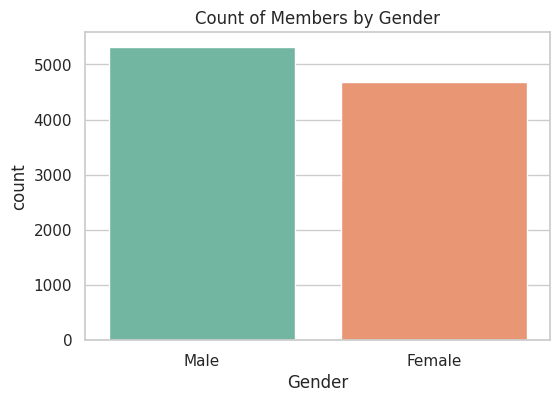

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='Gender', palette='Set2')
plt.title('Count of Members by Gender')
plt.show()

/tmp/ipykernel_13099/1308916829.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Workout_Type', palette='Set3', order=data['Workout_Type'].value_counts().index)


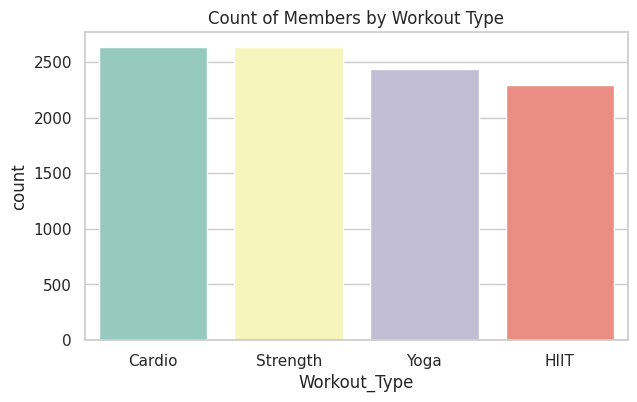

In [14]:
plt.figure(figsize=(7, 4))
sns.countplot(data=data, x='Workout_Type', palette='Set3', order=data['Workout_Type'].value_counts().index)
plt.title('Count of Members by Workout Type')
plt.show()

/tmp/ipykernel_13099/1333108589.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Experience_Level', palette='pastel')


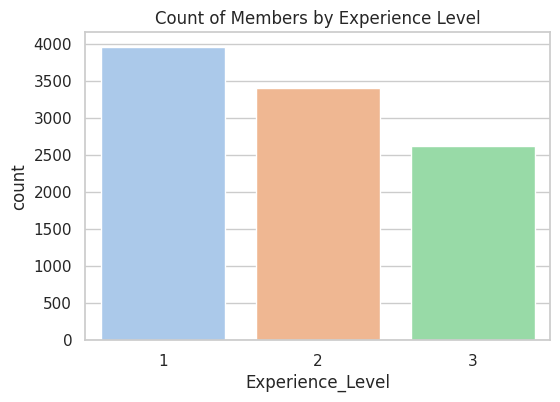

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='Experience_Level', palette='pastel')
plt.title('Count of Members by Experience Level')
plt.show()

/tmp/ipykernel_13099/4167629699.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_calories.index, y=avg_calories.values, palette='viridis')


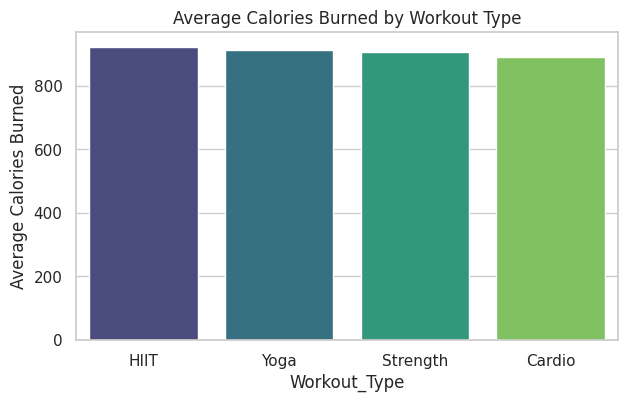

In [16]:
avg_calories = data.groupby('Workout_Type')['Calories_Burned'].mean().sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=avg_calories.index, y=avg_calories.values, palette='viridis')
plt.title('Average Calories Burned by Workout Type')
plt.ylabel('Average Calories Burned')
plt.show()

/tmp/ipykernel_13099/2778846536.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Workout_Type', y='Calories_Burned', palette='Set2')


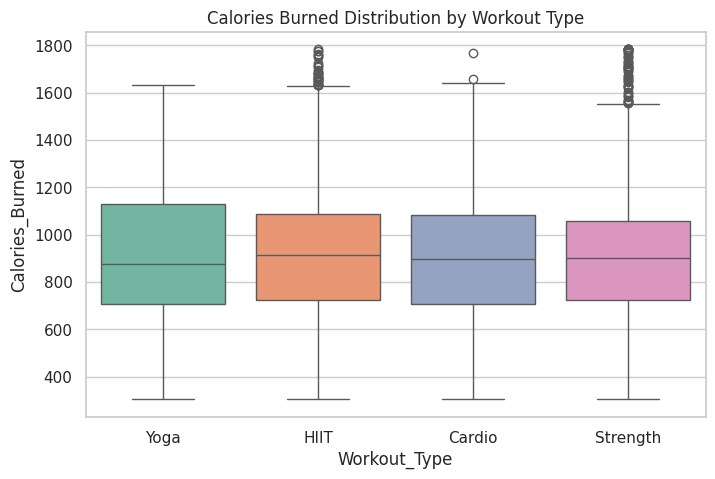

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='Workout_Type', y='Calories_Burned', palette='Set2')
plt.title('Calories Burned Distribution by Workout Type')
plt.show()

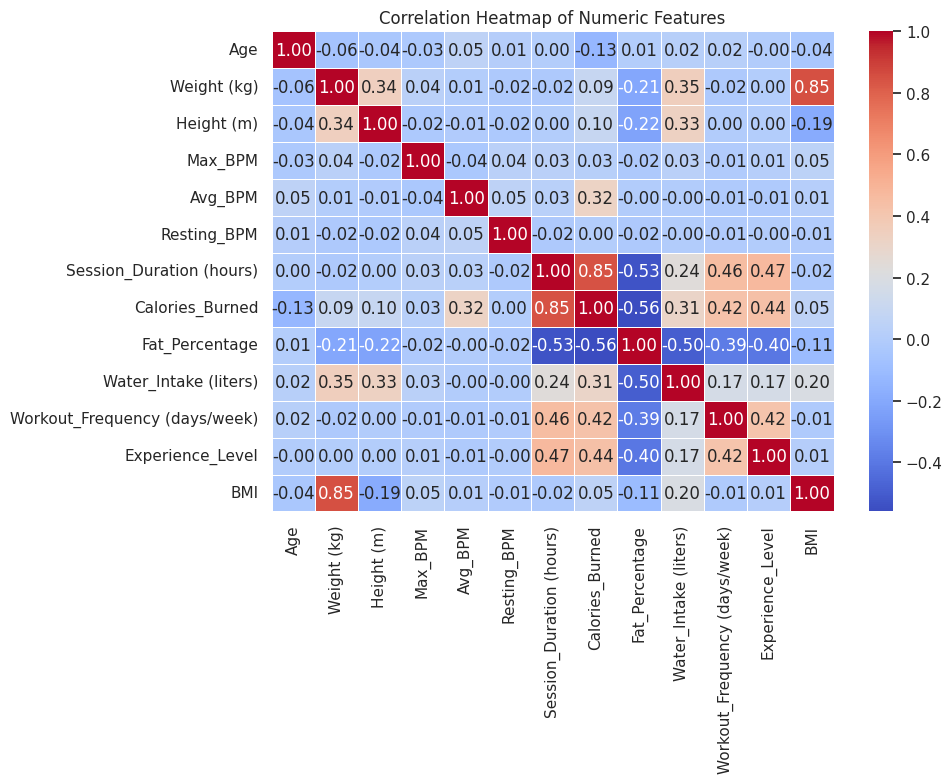

In [18]:
plt.figure(figsize=(10, 8))
corr = data[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

In [19]:
le_gender = LabelEncoder()
data["Gender"] = le_gender.fit_transform(data["Gender"])


In [20]:
le_target = LabelEncoder()
data["Workout_Type"] = le_target.fit_transform(data["Workout_Type"])

In [21]:
x = data.drop("Workout_Type", axis=1)
y = data["Workout_Type"]


print(y.shape)
print(x.shape)

(10000,)
(10000, 14)


In [22]:
x_train , x_test , y_train , y_test  = train_test_split(x,y,test_size = 0.2 , random_state=42,stratify=y)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 14)
(2000, 14)
(8000,)
(2000,)


In [23]:
x_train_processing = x_train.copy()
x_test_processing = x_test.copy()

In [24]:
x_train_encoded = pd.get_dummies(
    x_train_processing,
    columns=["Gender"],
    drop_first=True
)
x_test_encoded = pd.get_dummies(
    x_test_processing,
    columns=["Gender"],
    drop_first=True
)

In [25]:
scaler = StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train_encoded))
x_test_scaled = pd.DataFrame(scaler.transform(x_test_encoded))

In [26]:
x_train_scaled

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.526635,-1.604751,0.274512,1.113523,-0.329668,-0.972125,0.659589,0.011659,1.456480,-1.762317,-0.342096,1.417896,-1.783457,-1.065651
1,0.851148,0.013349,1.352880,1.113523,-0.818699,-1.374759,-1.657660,-1.633789,0.707681,-0.052556,0.622915,-1.083354,-0.644041,0.938394
2,1.013405,0.897225,2.046117,0.002447,-0.469391,-1.643181,-1.573904,-1.046900,0.754481,1.035474,-1.307107,-1.083354,-0.210328,0.938394
3,1.500175,-0.879879,1.892064,-0.424891,-1.098146,1.175254,-0.708426,-1.057702,-0.368717,0.413743,0.622915,0.167271,-1.579097,0.938394
4,1.662431,-0.992117,-1.343040,-1.365032,1.556595,-0.301069,-1.992684,-1.360148,0.816881,-0.985153,-1.307107,-1.083354,-0.432330,-1.065651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,1.337918,-0.501076,-1.034935,1.198990,-0.329668,-1.106336,0.408321,0.166482,0.785681,-1.451452,-1.307107,-1.083354,0.017555,-1.065651
7996,-0.609162,-0.646050,1.121801,-1.535967,-0.120083,1.577887,0.799182,-0.078355,0.099282,-1.762317,-1.307107,-1.083354,-1.138033,-1.065651
7997,0.283249,-0.566548,0.043433,-1.108630,1.486733,0.369987,0.240809,0.170083,0.551681,-1.451452,-0.342096,1.417896,-0.626399,-1.065651
7998,-0.203521,1.004786,1.044775,1.113523,-1.028284,0.369987,0.324565,0.238493,-0.571517,0.880041,-0.342096,-1.083354,0.389519,0.938394


In [27]:
x_test_scaled

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,-0.690291,0.490361,-0.264672,1.028055,0.578533,1.577887,2.083441,3.126128,-2.318714,1.346340,0.622915,1.417896,0.683562,0.938394
1,0.770020,0.373447,1.275854,0.258849,-0.678976,0.101564,0.408321,-0.153966,0.192882,0.880041,0.622915,0.167271,-0.294130,0.938394
2,0.120993,-0.926645,-0.880882,1.455393,-1.237869,0.906831,-0.624670,-0.888477,-0.275117,0.258310,-0.342096,-1.083354,-0.589643,0.938394
3,0.202121,0.560510,0.890722,-1.108630,0.159363,0.101564,-1.378474,-1.190922,0.458082,1.657206,-1.307107,-1.083354,0.066072,0.938394
4,-1.095932,-0.342071,-0.264672,1.369925,1.766180,0.235775,-1.183043,-0.845270,1.082080,-1.762317,-1.307107,0.167271,-0.232381,-1.065651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.932276,-0.285952,-1.728171,-0.424891,-0.469391,-1.240547,0.659589,-0.243979,-0.212717,-1.606884,-1.307107,-1.083354,0.774715,-1.065651
1996,0.688891,-1.010824,-1.728171,-1.194097,-1.028284,1.041042,0.910857,-0.982091,0.426882,-0.829720,1.587926,0.167271,-0.238262,-1.065651
1997,-0.609162,-0.959381,0.890722,-1.108630,-1.098146,0.369987,-0.931775,-0.200773,0.317682,-0.207989,0.622915,1.417896,-1.345333,-1.065651
1998,0.445506,1.074935,0.967749,0.173381,0.857979,0.369987,0.157053,0.533738,0.286482,1.035474,-1.307107,0.167271,0.498315,0.938394


In [28]:
model = LogisticRegression(max_iter = 1000)
model.fit(x_train_scaled , y_train)

LogisticRegression(max_iter=1000)

In [29]:
l_pred = model.predict(x_test_scaled)
l_pred[:10]

array([1, 3, 1, 0, 0, 0, 0, 0, 3, 2])

In [30]:
y_prop = y_pred = model.predict_proba(x_test_scaled)
y_prop[:10]

array([[0.23207279, 0.29088221, 0.23613727, 0.24090772],
       [0.20839087, 0.23188869, 0.27037046, 0.28934998],
       [0.22001876, 0.26288993, 0.25752888, 0.25956243],
       [0.29360989, 0.21102832, 0.27453607, 0.22082572],
       [0.34827811, 0.19481374, 0.19241913, 0.26448902],
       [0.36083709, 0.22451433, 0.18619881, 0.22844978],
       [0.32139245, 0.2273548 , 0.26931079, 0.18194195],
       [0.25862037, 0.25114137, 0.23192196, 0.2583163 ],
       [0.26553138, 0.19498926, 0.23391633, 0.30556302],
       [0.23576903, 0.23033072, 0.3205229 , 0.21337735]])

In [31]:
y_pred = model.predict(x_test_scaled)
y_pred[:10]

array([1, 3, 1, 0, 0, 0, 0, 0, 3, 2])

In [32]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy}")

Accuracy : 0.3025


In [33]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[196,  30, 177, 124],
       [136,  36, 171, 115],
       [135,  55, 220, 117],
       [138,  22, 175, 153]])

In [34]:
precision = precision_score(y_test,y_pred, average='weighted')
recall = recall_score(y_test,y_pred, average='weighted')
f1 = f1_score(y_test,y_pred, average='weighted')
print(f"precision : {precision}")
print(f"recall : {recall}")
print(f"f1:{f1}")

precision : 0.29438098462176293
recall : 0.3025
f1:0.2848616306103155


In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.32      0.37      0.35       527
           1       0.25      0.08      0.12       458
           2       0.30      0.42      0.35       527
           3       0.30      0.31      0.31       488

    accuracy                           0.30      2000
   macro avg       0.29      0.30      0.28      2000
weighted avg       0.29      0.30      0.28      2000



In [36]:
model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)

model.fit(x_train_encoded, y_train)
preds = model.predict(x_test_encoded)
mean_squared_error(y_test, preds)

1.206394788095549

In [37]:
model = GaussianMixture(
    n_components= 3,
    covariance_type="full",
    random_state=42,
    n_init=5,
    init_params="kmeans",
    max_iter=300,
)
model.fit(x_train_scaled)
labels = model.predict(x_train_scaled)
print(f"BIC: {model.bic(x_train_scaled):.2f}")
print(f"AIC: {model.aic(x_train_scaled):.2f}")

BIC: 125163.49
AIC: 122655.09


In [38]:
daf = data.copy()
print('Dataset shape:', daf.shape)
print('Classes:', sorted(daf['Workout_Type'].unique()))
daf.head(10)

Dataset shape: (10000, 15)
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,3,12.6,3.5,4,3,30.20
1,46,0,74.9,1.53,179,151,66,1.30,883.0,1,33.9,2.1,4,2,32.00
2,32,0,68.1,1.66,167,122,54,1.11,677.0,0,33.4,2.3,4,2,24.71
3,25,1,53.2,1.70,190,164,56,0.59,532.0,2,28.8,2.1,3,1,18.41
4,38,1,46.1,1.79,188,158,68,0.64,556.0,2,29.2,2.8,3,1,14.39
5,56,0,58.0,1.68,168,156,74,1.59,1116.0,1,15.5,2.7,5,3,20.55
6,36,1,70.3,1.72,174,169,73,1.49,1385.0,0,21.3,2.3,3,2,23.76
7,40,0,69.7,1.51,189,141,64,1.27,895.0,0,30.6,1.9,3,2,30.57
8,28,1,121.7,1.94,185,127,52,1.03,719.0,2,28.9,2.6,4,2,32.34
9,28,1,101.8,1.84,169,136,64,1.08,808.0,0,29.7,2.7,3,1,30.07


In [39]:
print('Samples per Workout Type:')
print(daf['Workout_Type'].value_counts())

Samples per Workout Type:
Workout_Type
0    2637
2    2633
3    2439
1    2291
Name: count, dtype: int64


In [40]:
print(f'  Mean per feature: {x_train_scaled.mean(axis=0).round(6)}')
print(f'  Std  per feature: {x_train_scaled.std(axis=0).round(6)}')

  Mean per feature: 0    -0.0
1     0.0
2     0.0
3     0.0
4     0.0
5    -0.0
6    -0.0
7    -0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
dtype: float64
  Std  per feature: 0     1.000063
1     1.000063
2     1.000063
3     1.000063
4     1.000063
5     1.000063
6     1.000063
7     1.000063
8     1.000063
9     1.000063
10    1.000063
11    1.000063
12    1.000063
13    1.000063
dtype: float64


In [41]:
knn = KNeighborsClassifier(n_neighbors=5,metric='euclidean')
knn.fit(x_train, y_train)
y_pred_2 = knn.predict(x_test)

In [42]:
print("Accuracy =", accuracy_score(y_test, y_pred_2))

Accuracy = 0.5565


In [43]:
print(classification_report(y_test, y_pred_2))

              precision    recall  f1-score   support

           0       0.52      0.66      0.58       527
           1       0.55      0.60      0.58       458
           2       0.56      0.48      0.51       527
           3       0.62      0.49      0.55       488

    accuracy                           0.56      2000
   macro avg       0.56      0.56      0.55      2000
weighted avg       0.56      0.56      0.55      2000



In [44]:
cm = confusion_matrix(y_test, y_pred_2)

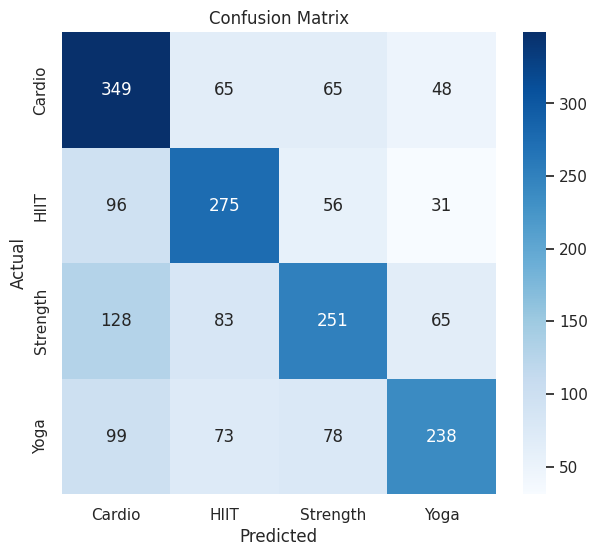

In [45]:
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
   xticklabels=le_target.classes_,
  yticklabels=le_target.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [46]:
k_values = range(1, 21)
accuracy = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)

    accuracy.append(acc)

best_k = k_values[accuracy.index(max(accuracy))]

print("Best K =", best_k)
print("Best Accuracy =", max(accuracy))

Best K = 1
Best Accuracy = 0.684


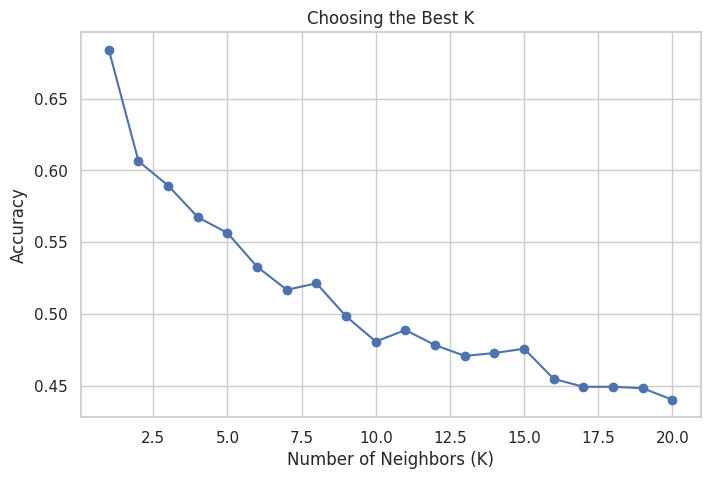

In [47]:
plt.figure(figsize=(8,5))

plt.plot(k_values, accuracy, marker='o')

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("Choosing the Best K")
plt.grid(True)

plt.show()

In [48]:
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Final Accuracy: 0.684
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       527
           1       0.66      0.72      0.69       458
           2       0.69      0.63      0.66       527
           3       0.68      0.68      0.68       488

    accuracy                           0.68      2000
   macro avg       0.68      0.69      0.68      2000
weighted avg       0.68      0.68      0.68      2000

